In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

plt.style.use('seaborn-v0_8')
print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
df = pd.read_csv('../data/train.csv', low_memory=False)
print("Columns found:", df.columns.tolist())
print("Shape:", df.shape)
df.head()


Columns found: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']
Shape: (1017209, 9)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("Total Stores:", df['Store'].nunique())
print("Missing values:\n", df.isnull().sum())
print("\nSales stats:")
df['Sales'].describe()

Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00
Total Stores: 1115
Missing values:
 Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

Sales stats:


count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

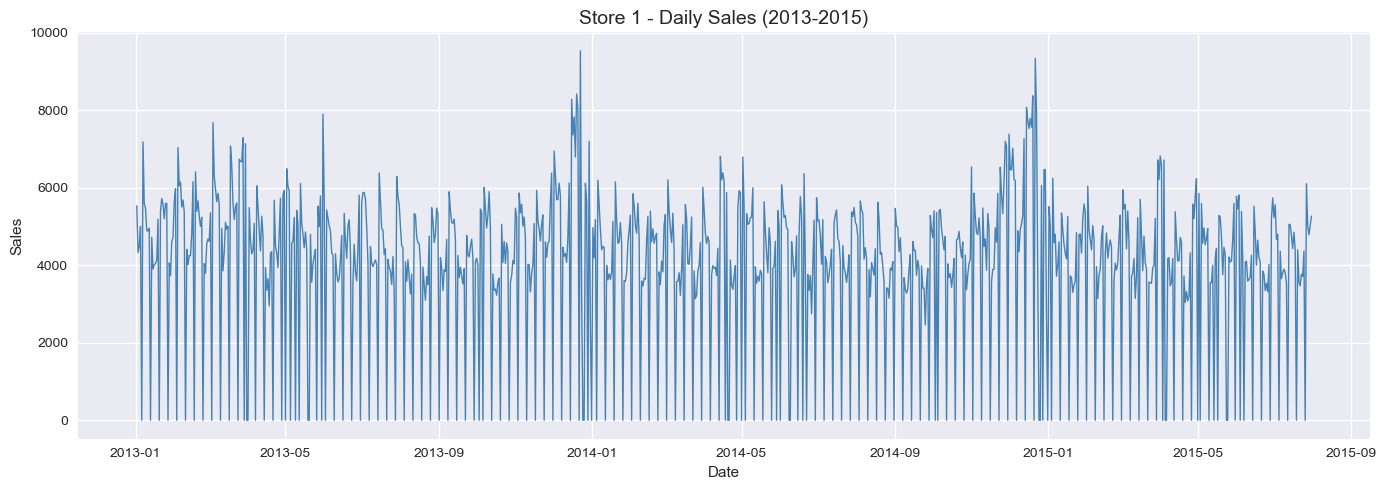

Chart saved!


In [8]:
# Focus on Store 1 for forecasting
df_store1 = df[df['Store'] == 1].copy()
df_store1 = df_store1[df_store1['Open'] == 1]  # only open days
df_store1 = df_store1.set_index('Date').resample('D')['Sales'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(df_store1['Date'], df_store1['Sales'], color='steelblue', linewidth=1)
plt.title('Store 1 - Daily Sales (2013-2015)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.tight_layout()
plt.savefig('../reports/01_sales_trend.png', dpi=150)
plt.show()
print("Chart saved!")


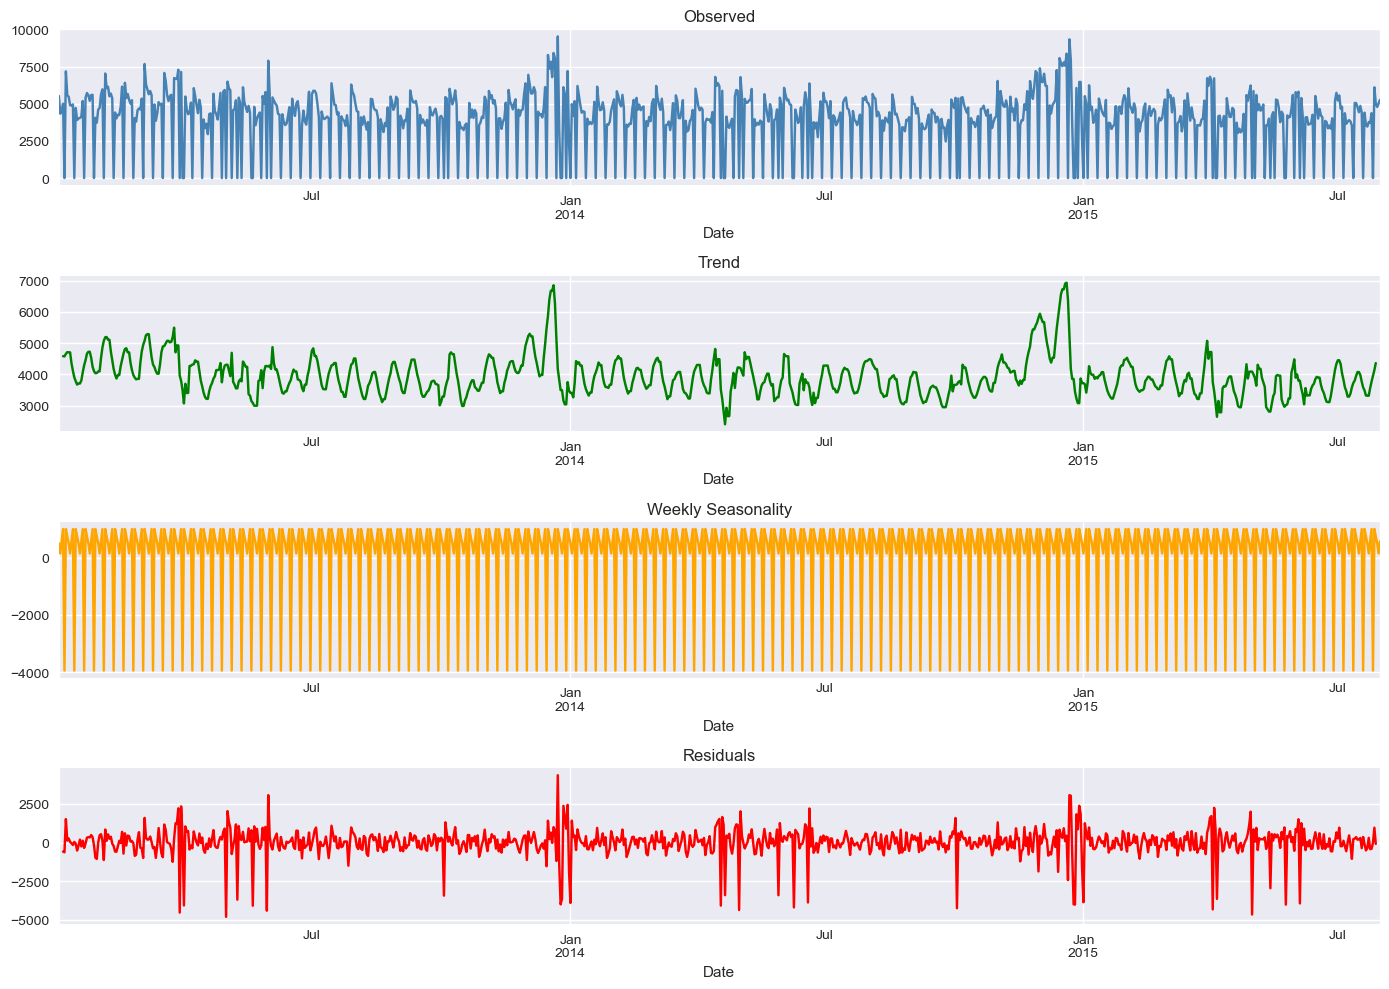

Decomposition saved!


In [9]:
# Seasonal decomposition
df_decomp = df_store1.set_index('Date')['Sales']

decomposition = seasonal_decompose(df_decomp, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], title='Observed', color='steelblue')
decomposition.trend.plot(ax=axes[1], title='Trend', color='green')
decomposition.seasonal.plot(ax=axes[2], title='Weekly Seasonality', color='orange')
decomposition.resid.plot(ax=axes[3], title='Residuals', color='red')
plt.tight_layout()
plt.savefig('../reports/02_decomposition.png', dpi=150)
plt.show()
print("Decomposition saved!")

In [10]:
# Stationarity test
df_decomp_clean = df_decomp.dropna()
result = adfuller(df_decomp_clean)
print("=== ADF Stationarity Test ===")
print(f"ADF Statistic : {round(result[0], 4)}")
print(f"p-value       : {round(result[1], 4)}")
print(f"Critical Values:")
for key, val in result[4].items():
    print(f"   {key}: {round(val, 4)}")

if result[1] < 0.05:
    print("\nResult: STATIONARY - Ready for ARIMA!")
else:
    print("\nResult: NON-STATIONARY - Needs differencing")

# Save cleaned data for modelling
df_store1.to_csv('../data/store1_clean.csv', index=False)
print("\nClean data saved to data/store1_clean.csv")
print("EDA Complete!")

=== ADF Stationarity Test ===
ADF Statistic : -4.366
p-value       : 0.0003
Critical Values:
   1%: -3.4375
   5%: -2.8647
   10%: -2.5684

Result: STATIONARY - Ready for ARIMA!

Clean data saved to data/store1_clean.csv
EDA Complete!
